# Clustering Assignment


1.	What is unsupervised learning in the context of machine learning?
    -	Unsupervised learning is a type of machine learning where algorithms are trained on unlabeled data to discover hidden patterns, structures, or groupings on their own without human intervention.

2.	How does K-Means clustering algorithm work?
    -	The K-Means clustering algorithm works by iteratively partitioning a dataset into K distinct clusters, where each data point is assigned to its nearest cluster center (centroid) and the centroids are continuously recalculated until cluster assignments stabilize.

3.	Explain the concept of a dendrogram in hierarchical clustering¬.
    -	A dendrogram is a tree-like diagram that visually records the sequences of merges or splits that occur during hierarchical clustering.

4.	What is the main difference between K-Means and Hierarchical Clustering?
    -	The main difference between K-Means and Hierarchical Clustering is that K-Means requires you to predefine the number of clusters (K) and divides data into flat, non-overlapping groups, whereas Hierarchical Clustering builds a nested tree of clusters without needing K in advance.

5.	What are the advantages of DBSCAN over K-Means?
    -	DBSCAN (Density-Based Spatial Clustering of Applications with Noise) has major advantages over K-Means because it does not require you to predefine the number of clusters, can discover clusters of arbitrary shapes, and automatically identifies noise and outliers.

6.	When would you use Silhouette Score in clustering?
    -	You use the Silhouette Score in clustering to measure how well-separated and internally cohesive your clusters are without needing ground-truth labels.

7.	What are the limitations of Hierarchical Clustering?
    -	The main limitations of Hierarchical Clustering are its high computational complexity, high memory requirements, and its inability to undo or correct a bad split or merge step once it has been executed.

8.	Why is feature scaling important in clustering algorithms like K-Means?
    -	Feature scaling is vital in K-Means clustering because the algorithm relies heavily on distance calculations (like Euclidean distance), meaning unscaled features with larger numerical ranges will completely dominate and bias the distance metrics over features with smaller ranges.

9.	How does DBSCAN identify noise points?
    -	DBSCAN identifies a data point as a noise point (or outlier) if it is located in a low-density region that satisfies two specific conditions based on the algorithm's hyperparameters:
It is not a Core Point: The point has fewer than min_samples (or minPts) neighboring points within its radius of distance
It is not a Border Point: The point does not fall within the eps radius of any core point in the dataset (meaning it is not density-reachable from any cluster).

10.	Define inertia in the context of K-Means¬.
    -	In the context of K-Means clustering, inertia (also known as the Within-Cluster Sum of Squares, or WCSS) is the metric used to measure how internally coherent or tightly packed the clusters are.
    It calculates the sum of squared distances between each data point and its assigned cluster centroid.

11. What is the elbow method in K-Means clustering?
    -	The elbow method is a visual tool used to find the best number of clusters (k) in K-Means by plotting model inertia against different values of k and identifying the point where the rate of decrease sharply shifts.

12.	Describe the concept of "density" in DBSCAN¬.
    -	In DBSCAN (Density-Based Spatial Clustering of Applications with Noise), density is defined as the number of data points located within a specific, fixed geographic radius.

13. Can hierarchical clustering be used on categorical data?
    -	Yes, hierarchical clustering can be used on categorical data, but it requires specialized distance or dissimilarity metrics instead of standard numeric measures like Euclidean distance.
Because categorical attributes represent discrete groups rather than continuous coordinates, standard distance calculations do not work naturally.

14.	What does a negative Silhouette Score indicate?
    -	A negative Silhouette Score indicates that a data point has been assigned to the wrong cluster.
The silhouette score ranges from -1 to +1, where a negative value means a point is closer on average to the items in a neighboring cluster than to the items in its own assigned cluster.

15.	Explain the term "linkage criteria" in hierarchical clustering.
    -	In hierarchical clustering, linkage criteria determine how the distance between two clusters of data points is calculated.
While a distance metric (like Euclidean or Hamming distance) defines how to measure the gap between two individual points, the linkage criterion defines how to measure the gap between two entire groups of points. This rule dictates exactly how clusters are merged step-by-step up the dendrogram hierarchy.

16.	Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?
    -	K-Means clustering performs poorly on data with varying sizes or densities because it is fundamentally designed to find spherical, equally sized, and evenly dense clusters.
The algorithm relies on minimizing the global variance (inertia) using distance to a central point. When a dataset violates these assumptions, the mathematical logic of K-Means breaks down.

17.	What are the core parameters in DBSCAN, and how do they influence clustering?
    -	The two core parameters in DBSCAN are eps (epsilon) and min_samples (or minPts). Together, they define the minimum density threshold required to form a cluster, controlling how the algorithm separates dense groups from background noise.

18.	How does K-Means++ improve upon standard K-Means initialization?
    -	K-Means++ improves upon standard K-Means by using a smart, probabilistic initialization strategy to select initial cluster centroids that are far apart from one another.
Standard K-Means relies on random selection for its initial centroids, which frequently leads to poor convergence and suboptimal clustering.

19.	What is agglomerative clustering?
    -	Agglomerative clustering is a "bottom-up" hierarchical clustering technique where each data point starts in its own individual single-point cluster and pairs of clusters are successively merged together until all points form a single large cluster.

20.	What makes Silhouette Score a better metric than just inertia for model evaluation?
    -	While inertia is a quick metric to calculate, it has massive structural blind spots. Silhouette Score is a much more robust and complete metric for model evaluation for four key reasons:
It Accounts for Cluster Separation, Not Just Compactness
It Has an Absolute, Standardised Scale
It Doesn't Automatically Reward Overfitting
It Avoids the Ambiguity of the "Elbow Method"
    
    



       

            

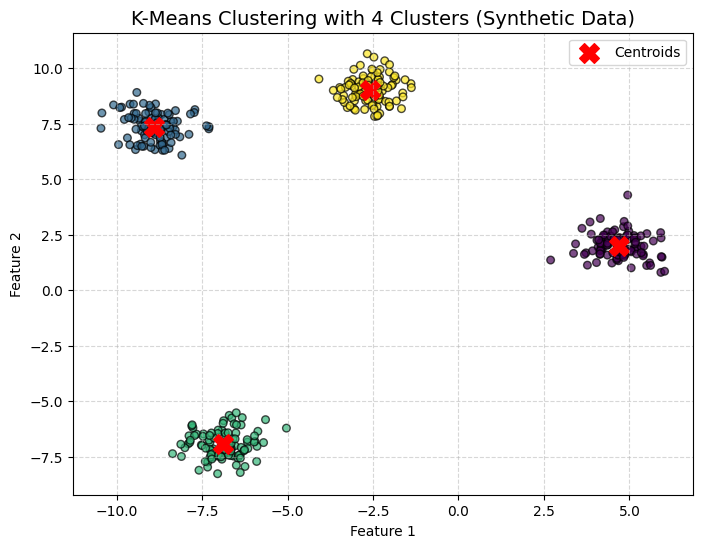

In [1]:
#Q21. Generate synthetic data with 4 centers using make_blobs and apply K-Means clustering. Visualize using a
#scatter plot
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 1. Generate synthetic data with 4 centers
X, y_true = make_blobs(n_samples=400, centers=4, cluster_std=0.60, random_state=42)

# 2. Apply K-Means clustering (using 4 clusters)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init='auto')
y_kmeans = kmeans.fit_predict(X)

# 3. Extract the calculated cluster centroids
centroids = kmeans.cluster_centers_

# 4. Create the scatter plot
plt.figure(figsize=(8, 6))

# Plot the data points color-coded by their cluster assignments
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=30, cmap='viridis', alpha=0.7, edgecolors='k')

# Plot the cluster centroids as prominent red 'X' markers
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')

plt.title('K-Means Clustering with 4 Clusters (Synthetic Data)', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [2]:
#Q22. Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters. Display the first 10
#predicted labels
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data

# 2. Configure and fit Agglomerative Clustering
# By default, scikit-learn uses 'ward' linkage and Euclidean distance
agg_model = AgglomerativeClustering(n_clusters=3)
predicted_labels = agg_model.fit_predict(X)

# 3. Print the first 10 cluster assignments
print("First 10 predicted labels:", list(predicted_labels[:10]))

First 10 predicted labels: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]


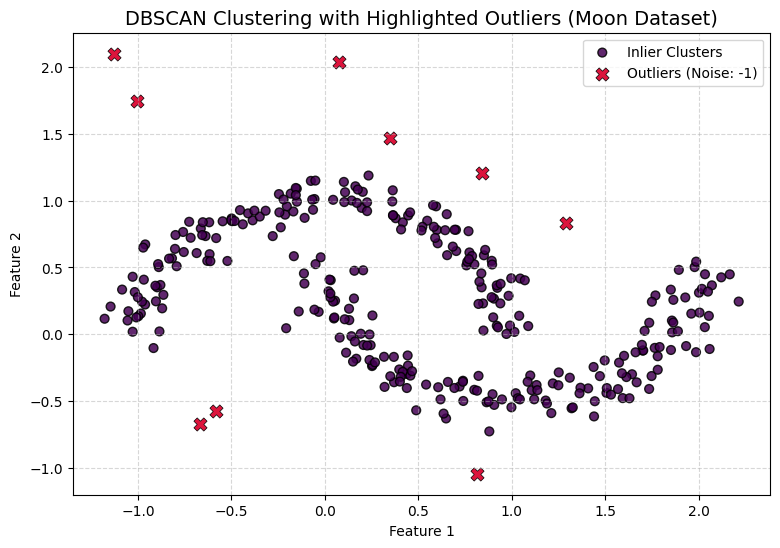

In [3]:
#Q23. Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers in the plot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

# 1. Generate synthetic interlocking moon data
X, y = make_moons(n_samples=300, noise=0.08, random_state=42)

# Add a few manual random outliers into the empty space to simulate true anomalies
np.random.seed(42)
extra_noise = np.random.uniform(low=-1.2, high=2.2, size=(15, 2))
X = np.vstack([X, extra_noise])

# 2. Run DBSCAN with fine-tuned parameters
# eps=0.2 defines our neighborhood radius, min_samples=5 demands at least 5 points to form a core
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# 3. Separate the valid cluster points from the noise points
# DBSCAN inherently flags noise points with a label value of -1
is_noise = (labels == -1)
is_cluster = ~is_noise

# 4. Generate the visualization plot
plt.figure(figsize=(9, 6))

# Plot the valid clustered data points (color-coded by their designated cluster labels)
plt.scatter(X[is_cluster, 0], X[is_cluster, 1], c=labels[is_cluster],
            cmap='viridis', s=40, edgecolors='k', alpha=0.85, label='Inlier Clusters')

# Highlight the outliers prominently in red using a distinct 'X' marker
plt.scatter(X[is_noise, 0], X[is_noise, 1], c='crimson', marker='X',
            s=90, edgecolors='black', linewidths=0.5, label='Outliers (Noise: -1)')

plt.title('DBSCAN Clustering with Highlighted Outliers (Moon Dataset)', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [4]:
#Q24. Load the Wine dataset and apply K-Means clustering after standardizing the features. Print the size of each
#cluster.
import collections
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load the Wine dataset
wine = load_wine()
X = wine.data

# 2. Standardize features to have a mean of 0 and variance of 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Instantiate and fit the K-Means algorithm
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)

# 4. Count and display the size of each cluster
cluster_sizes = collections.Counter(labels)
for cluster_id, size in sorted(cluster_sizes.items()):
    print(f"Cluster {cluster_id}: {size} samples")


Cluster 0: 65 samples
Cluster 1: 51 samples
Cluster 2: 62 samples


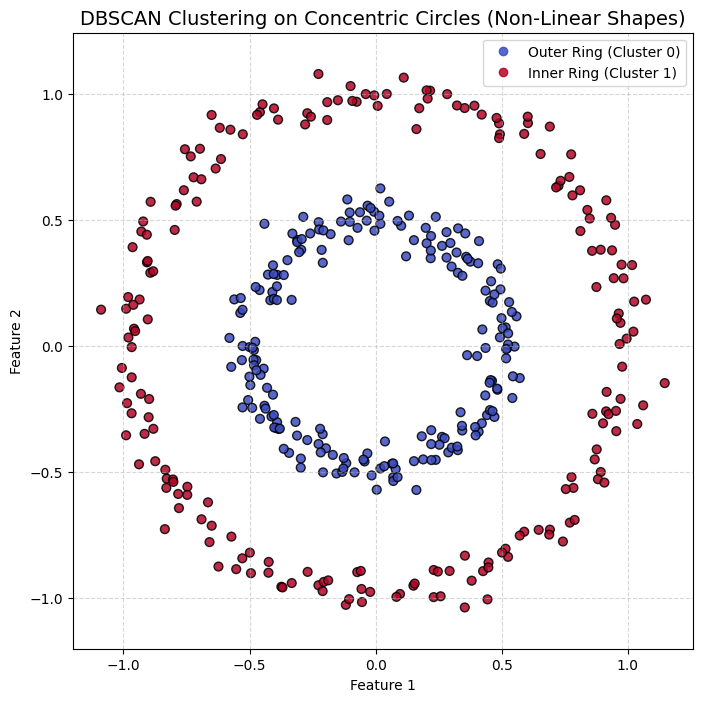

In [5]:
#Q25. Use make_circles to generate synthetic data and cluster it using DBSCAN. Plot the result
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN

# 1. Generate concentric circles dataset
# factor=0.5 sets the ratio of the inner ring radius to the outer ring radius
X, y = make_circles(n_samples=400, factor=0.5, noise=0.05, random_state=42)

# 2. Run DBSCAN with fine-tuned parameters
# eps=0.15 is wide enough to bridge neighboring points on a circle, but too narrow to bridge the gap between rings
dbscan = DBSCAN(eps=0.15, min_samples=5)
labels = dbscan.fit_predict(X)

# 3. Plot the final clustering result
plt.figure(figsize=(8, 8))

# Scatter plot color-coded by the discovered DBSCAN cluster assignments
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='coolwarm', s=40, edgecolors='k', alpha=0.85)

plt.title('DBSCAN Clustering on Concentric Circles (Non-Linear Shapes)', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.5)

# Add a clean legend based on the unique clusters identified
handles, _ = scatter.legend_elements()
plt.legend(handles, ['Outer Ring (Cluster 0)', 'Inner Ring (Cluster 1)'], loc='upper right')

plt.axis('equal')  # Enforce equal aspect ratio to keep circles perfectly round
plt.show()

In [6]:
#Q26.  Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. Output the cluster
#centroids
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# 1. Load the Breast Cancer dataset
cancer_data = load_breast_cancer()
X = cancer_data.data

# 2. Transform the coordinates using MinMaxScaler (bounds features between 0 and 1)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fit K-Means with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeans.fit(X_scaled)

# 4. Extract and round the cluster centroids
centroids = np.round(kmeans.cluster_centers_, 4)

print("Cluster 0 Centroid:\n", centroids[0].tolist())
print("\nCluster 1 Centroid:\n", centroids[1].tolist())


Cluster 0 Centroid:
 [0.5048, 0.3956, 0.5058, 0.3638, 0.4699, 0.4223, 0.4184, 0.4693, 0.459, 0.2995, 0.1909, 0.1911, 0.179, 0.1309, 0.1802, 0.2589, 0.1254, 0.3094, 0.1901, 0.1327, 0.4805, 0.4511, 0.4655, 0.3146, 0.4987, 0.3639, 0.3903, 0.6583, 0.3375, 0.2604]

Cluster 1 Centroid:
 [0.2554, 0.2883, 0.247, 0.1439, 0.3574, 0.1802, 0.1034, 0.1307, 0.3401, 0.2559, 0.0643, 0.1884, 0.0598, 0.0287, 0.1816, 0.1324, 0.0582, 0.1807, 0.1722, 0.084, 0.2052, 0.3207, 0.1924, 0.0994, 0.3571, 0.1487, 0.1314, 0.2623, 0.2264, 0.1544]


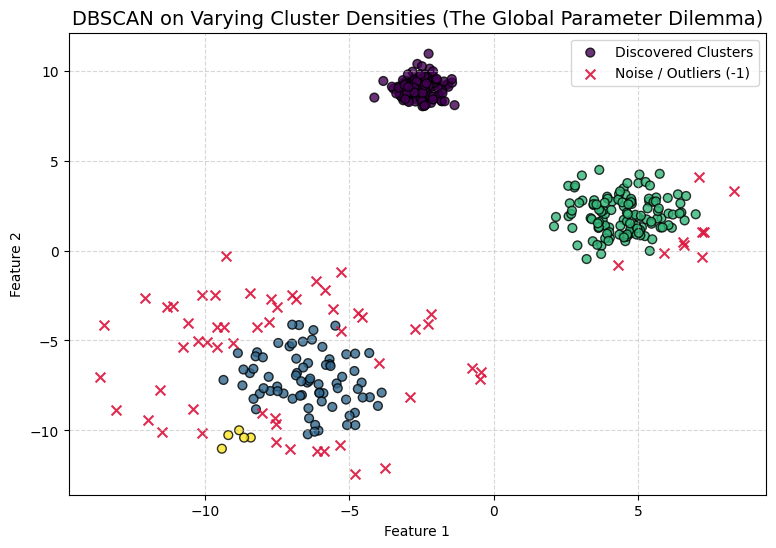

In [7]:
#Q27. Generate synthetic data using make_blobs with varying cluster standard deviations and cluster with
#DBSCAN
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

# 1. Generate 3 clusters with radically different densities (varying standard deviations)
# Cluster 1 is highly compact (0.5), Cluster 2 is balanced (1.2), Cluster 3 is highly sparse (2.5)
X, y_true = make_blobs(n_samples=400, centers=3, cluster_std=[0.5, 1.2, 2.5], random_state=42)

# 2. Apply DBSCAN
# We choose a global threshold. Let's look at the dilemma of setting 'eps' here.
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels = dbscan.fit_predict(X)

# 3. Identify noise points marked by DBSCAN as -1
is_noise = (labels == -1)
is_cluster = ~is_noise

# 4. Visualize the results
plt.figure(figsize=(9, 6))

# Plot valid cluster members color-coded by their labels
scatter = plt.scatter(X[is_cluster, 0], X[is_cluster, 1], c=labels[is_cluster],
            cmap='viridis', s=40, edgecolors='k', alpha=0.8, label='Discovered Clusters')

# Highlight the noise points/outliers prominently in red
plt.scatter(X[is_noise, 0], X[is_noise, 1], c='crimson', marker='x',
            s=50, alpha=0.9, label='Noise / Outliers (-1)')

plt.title('DBSCAN on Varying Cluster Densities (The Global Parameter Dilemma)', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()


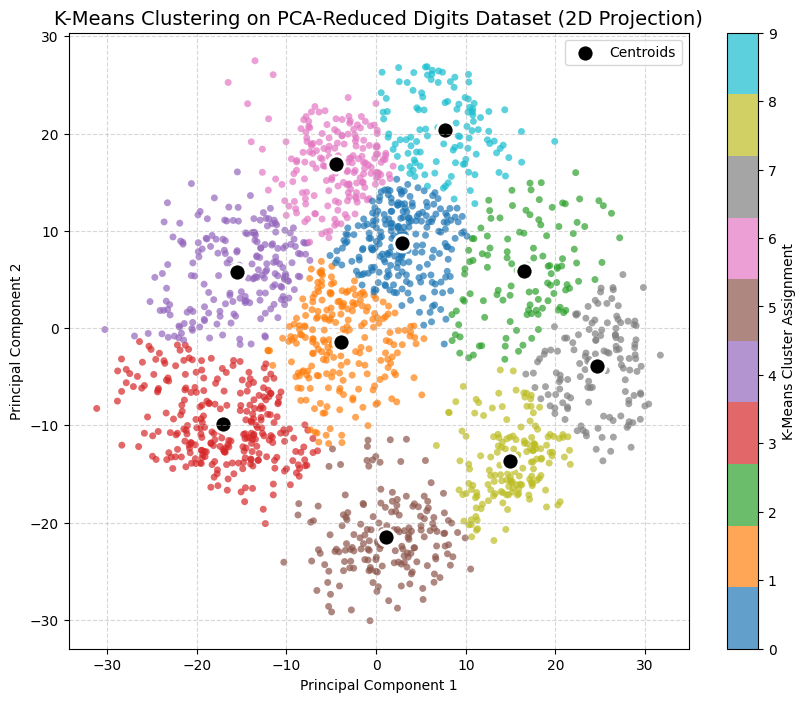

In [8]:
#Q28. Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Load the Digits dataset (8x8 pixel images unrolled into 64 features)
digits = load_digits()
X = digits.data

# 2. Reduce the 64-dimensional pixel array down to 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# 3. Apply K-Means clustering (using 10 clusters to mirror digits 0-9)
kmeans = KMeans(n_clusters=10, random_state=42, n_init='auto')
y_kmeans = kmeans.fit_predict(X_pca)
centroids = kmeans.cluster_centers_

# 4. Generate the visualization plot
plt.figure(figsize=(10, 8))

# Scatter plot of the 2D projected data points color-coded by K-Means assignments
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='tab10',
            s=25, alpha=0.7, edgecolors='none')

# Overlay the calculated cluster centroids prominently as large black circles
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='o',
            s=150, linewidths=2, edgecolors='white', label='Centroids')

plt.title('K-Means Clustering on PCA-Reduced Digits Dataset (2D Projection)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Add a color bar mapping to the 10 distinct cluster IDs
colorbar = plt.colorbar(scatter)
colorbar.set_label('K-Means Cluster Assignment')

plt.show()

For k = 2, Average Silhouette Score: 0.6155
For k = 3, Average Silhouette Score: 0.7993
For k = 4, Average Silhouette Score: 0.8756
For k = 5, Average Silhouette Score: 0.7552


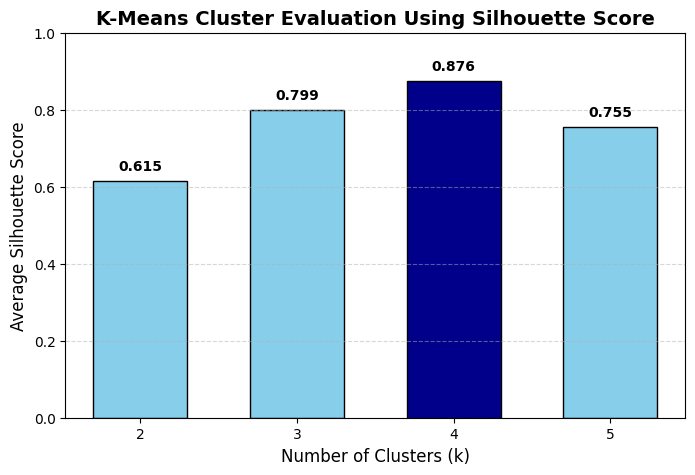

In [9]:
#29.  Create synthetic data using make_blobs and evaluate silhouette scores for k = 2 to 5. Display as a bar chart
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Generate synthetic data with 4 natural clusters
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

# 2. Iterate through k=2 to k=5 to track silhouette scores
k_values = range(2, 6)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"For k = {k}, Average Silhouette Score: {score:.4f}")

# 3. Plot the silhouette scores using a bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(k_values, silhouette_scores, color='skyblue', edgecolor='black', width=0.6)

# Highlight the highest scoring bar (the optimal k configuration)
max_idx = silhouette_scores.index(max(silhouette_scores))
bars[max_idx].set_color('darkblue')
bars[max_idx].set_edgecolor('black')

# Add numeric value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.02, f'{height:.3f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('K-Means Cluster Evaluation Using Silhouette Score', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Average Silhouette Score', fontsize=12)
plt.xticks(k_values)
plt.ylim(0, 1.0)  # Silhouette score bounds scale between -1 and +1
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


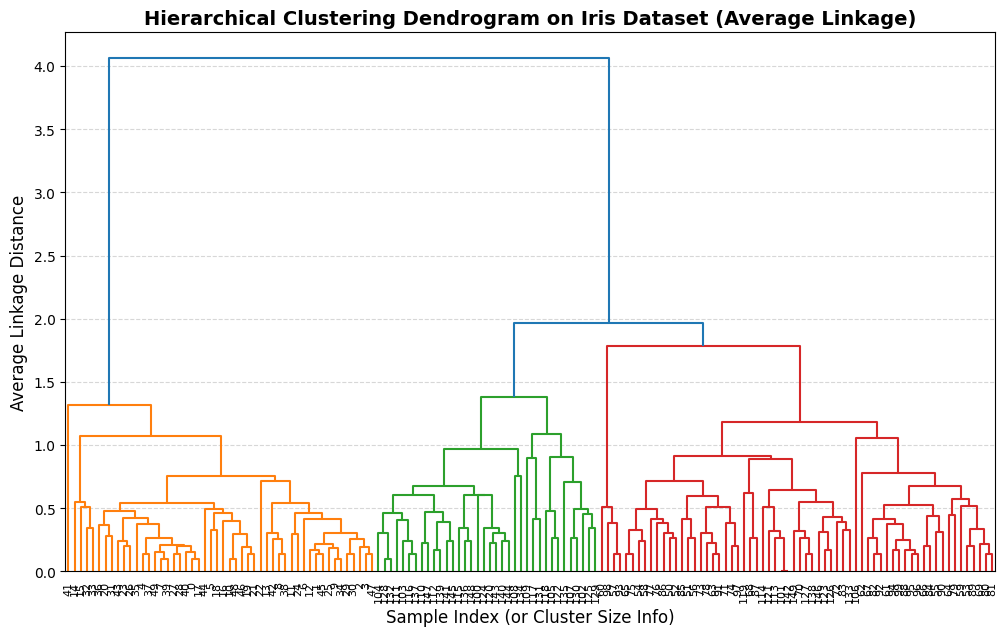

In [10]:
#Q30. Load the Iris dataset and use hierarchical clustering to group data. Plot a dendrogram with average linkage
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data

# 2. Compute the hierarchical clustering linkage matrix
# We use 'average' linkage to compute distances based on mean cluster pairing
Z = linkage(X, method='average', metric='euclidean')

# 3. Plot the dendrogram tree structure
plt.figure(figsize=(12, 7))
dendrogram(
    Z,
    leaf_rotation=90.,  # Rotates the x-axis sample indices for better readability
    leaf_font_size=8.,   # Font size for the leaf nodes
    color_threshold=1.8  # Colorizes distinct major branches below a specific distance threshold
)

plt.title('Hierarchical Clustering Dendrogram on Iris Dataset (Average Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index (or Cluster Size Info)', fontsize=12)
plt.ylabel('Average Linkage Distance', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

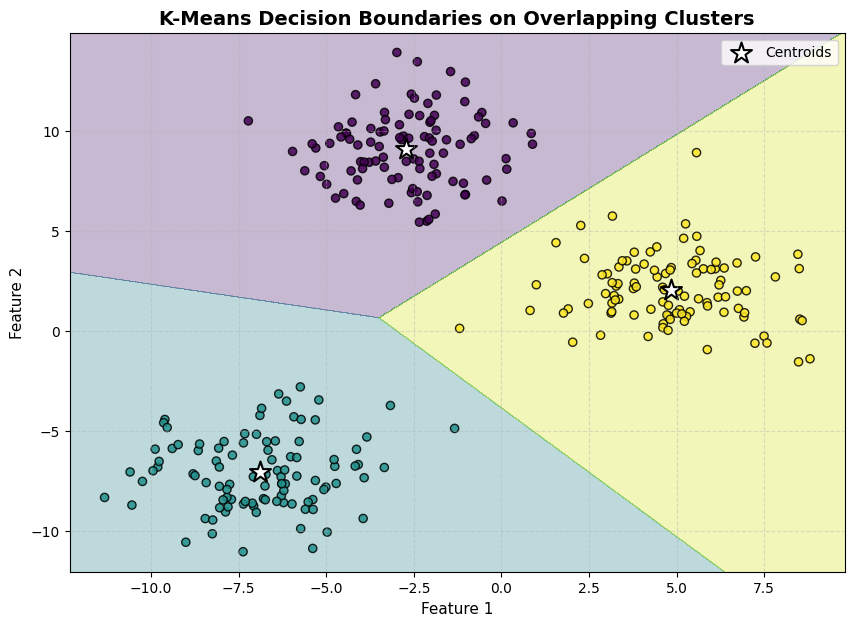

In [11]:
#Q31.  Generate synthetic data with overlapping clusters using make_blobs, then apply K-Means and visualize with
#decision boundaries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 1. Generate synthetic data with overlapping clusters (high standard deviation)
# By setting cluster_std to 1.8, the blobs expand and heavily bleed into each other
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.8, random_state=42)

# 2. Fit K-Means to the data
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X)

# 3. Create a mesh grid to plot the decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 4. Predict the cluster assignment for every coordinate cell on the mesh grid
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Plot the decision boundaries and data points
plt.figure(figsize=(10, 7))

# Draw the background decision regions (Voronoi Tessellation)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

# Plot the original data points color-coded by their predicted K-Means labels
scatter = plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis',
            s=35, edgecolors='k', alpha=0.85)

# Plot the final calculated cluster centroids as large white stars
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='white', marker='*',
            s=250, edgecolors='black', linewidths=1.5, label='Centroids')

plt.title('K-Means Decision Boundaries on Overlapping Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1', fontsize=11)
plt.ylabel('Feature 2', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()


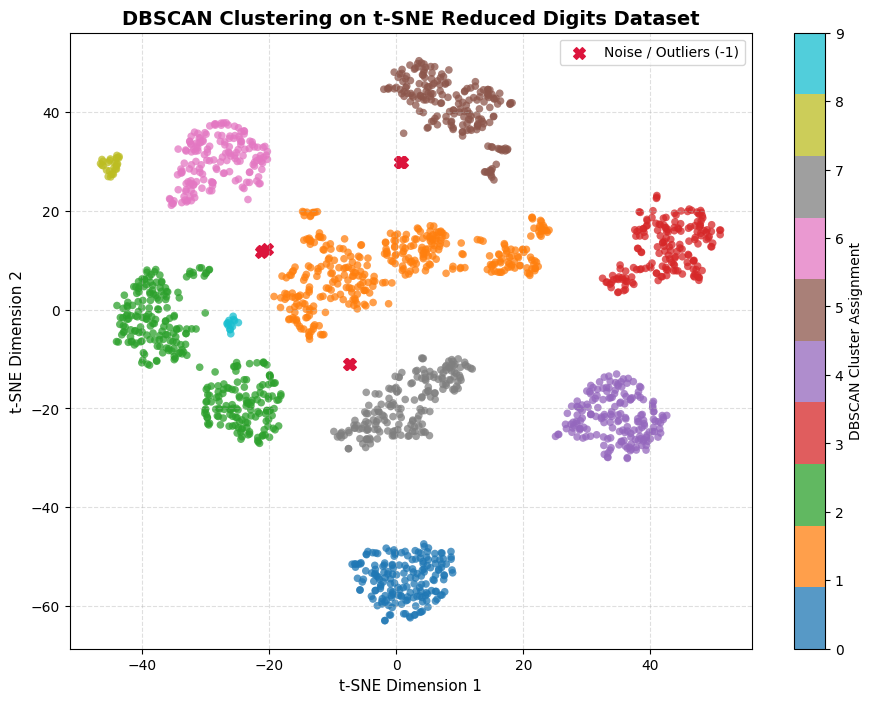

In [12]:
#Q32. Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize the results
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN

# 1. Load the Digits dataset (1797 images, each with 64 pixel features)
digits = load_digits()
X = digits.data

# 2. Reduce dimensions using t-SNE
# t-SNE preserves local neighborhoods, pushing different digits into distinct islands
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X)

# 3. Apply DBSCAN to the 2D t-SNE projection
# eps=4.5 and min_samples=10 are optimized for the spatial density fields created by t-SNE
dbscan = DBSCAN(eps=4.5, min_samples=10)
labels = dbscan.fit_predict(X_tsne)

# 4. Isolate cluster points from noise points
is_noise = (labels == -1)
is_cluster = ~is_noise

# 5. Visualize the results
plt.figure(figsize=(11, 8))

# Scatter plot of valid clusters discovered by DBSCAN
scatter = plt.scatter(X_tsne[is_cluster, 0], X_tsne[is_cluster, 1],
            c=labels[is_cluster], cmap='tab10', s=30, alpha=0.75, edgecolors='none')

# Highlight the anomalous noise points / outliers in bright red
plt.scatter(X_tsne[is_noise, 0], X_tsne[is_noise, 1],
            c='crimson', marker='X', s=70, label='Noise / Outliers (-1)')

plt.title('DBSCAN Clustering on t-SNE Reduced Digits Dataset', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Dimension 1', fontsize=11)
plt.ylabel('t-SNE Dimension 2', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper right')

# Add a color bar map for the generated clusters
colorbar = plt.colorbar(scatter)
colorbar.set_label('DBSCAN Cluster Assignment')

plt.show()


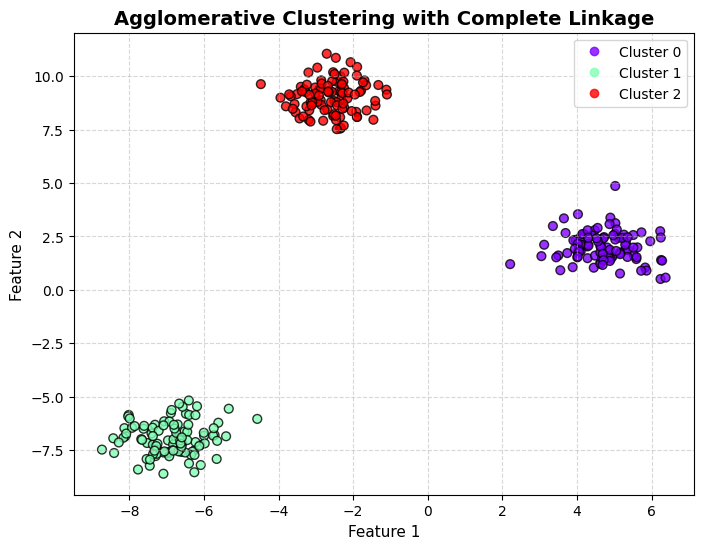

In [13]:
#Q33. Generate synthetic data using make_blobs and apply Agglomerative Clustering with complete linkage. Plot
#the result
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

# 1. Generate synthetic data with 3 natural centers
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.75, random_state=42)

# 2. Apply Agglomerative Clustering using complete linkage
# Complete linkage defines cluster distance by the furthest pair of points between them
agg_model = AgglomerativeClustering(n_clusters=3, linkage='complete')
y_predicted = agg_model.fit_predict(X)

# 3. Create the scatter plot visualization
plt.figure(figsize=(8, 6))

# Plot the data points color-coded by their agglomerative cluster labels
scatter = plt.scatter(X[:, 0], X[:, 1], c=y_predicted, cmap='rainbow', s=40, edgecolors='k', alpha=0.8)

plt.title('Agglomerative Clustering with Complete Linkage', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1', fontsize=11)
plt.ylabel('Feature 2', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Add a clear legend representing the unique discovered clusters
handles, _ = scatter.legend_elements()
plt.legend(handles, ['Cluster 0', 'Cluster 1', 'Cluster 2'], loc='upper right')

plt.show()


For k = 2, Inertia = 77943099.88
For k = 3, Inertia = 47264841.92
For k = 4, Inertia = 29226541.65
For k = 5, Inertia = 20539877.62
For k = 6, Inertia = 16573867.02


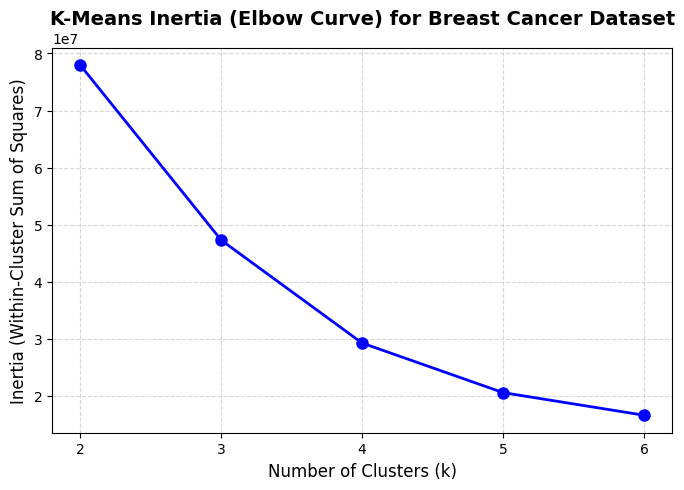

In [14]:
#Q34. Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 using K-Means. Show results in a
#line plot
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans

# 1. Load the raw Breast Cancer dataset
cancer_data = load_breast_cancer()
X = cancer_data.data

# 2. Compute inertia values across the range k = 2 to k = 6
k_values = range(2, 7)
inertia_values = []

for k in k_values:
    # Setting n_init=10 ensures a robust run with multiple random initializations
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)
    print(f"For k = {k}, Inertia = {kmeans.inertia_:.2f}")

# 3. Create the Elbow Method line plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

plt.title('K-Means Inertia (Elbow Curve) for Breast Cancer Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

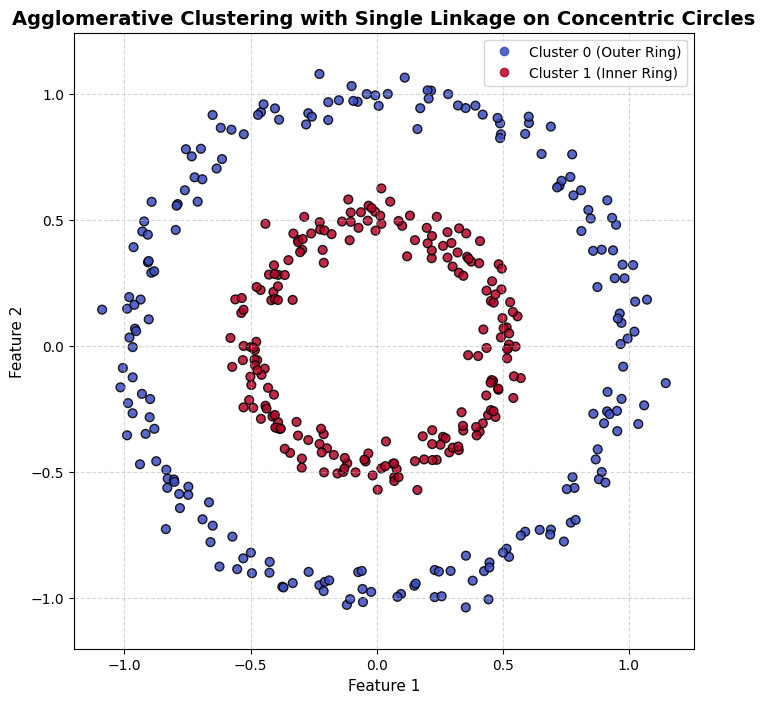

In [15]:
#Q35. Generate synthetic concentric circles using make_circles and cluster using Agglomerative Clustering with
#single linkage
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import AgglomerativeClustering

# 1. Generate synthetic concentric circles dataset
# factor=0.5 sets the ratio of the inner ring radius to the outer ring radius
X, y = make_circles(n_samples=400, factor=0.5, noise=0.05, random_state=42)

# 2. Apply Agglomerative Clustering using single linkage
# Single linkage defines cluster distance by the closest pair of points between them
agg_model = AgglomerativeClustering(n_clusters=2, linkage='single')
y_predicted = agg_model.fit_predict(X)

# 3. Create the scatter plot visualization
plt.figure(figsize=(8, 8))

# Scatter plot color-coded by the discovered agglomerative cluster assignments
scatter = plt.scatter(X[:, 0], X[:, 1], c=y_predicted, cmap='coolwarm', s=40, edgecolors='k', alpha=0.85)

plt.title('Agglomerative Clustering with Single Linkage on Concentric Circles', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1', fontsize=11)
plt.ylabel('Feature 2', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Add a clean legend based on the unique clusters identified
handles, _ = scatter.legend_elements()
plt.legend(handles, ['Cluster 0 (Outer Ring)', 'Cluster 1 (Inner Ring)'], loc='upper right')

plt.axis('equal')  # Enforce equal aspect ratio to keep circles perfectly round
plt.show()

In [16]:
#Q36. Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding
#noise)
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# 1. Load the raw Wine recognition dataset
wine = load_wine()
X = wine.data

# 2. Standardize features to have a mean of 0 and variance of 1
# This is crucial because distance measures are heavily distorted by unscaled variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply DBSCAN with parameters tuned for scaled 13-dimensional space
dbscan = DBSCAN(eps=2.5, min_samples=10)
labels = dbscan.fit_predict(X_scaled)

# 4. Count the number of valid clusters, ignoring noise points (labeled as -1)
unique_labels = set(labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = list(labels).count(-1)

print(f"Estimated number of clusters (excluding noise): {n_clusters}")
print(f"Estimated number of noise points: {n_noise}")

Estimated number of clusters (excluding noise): 2
Estimated number of noise points: 32


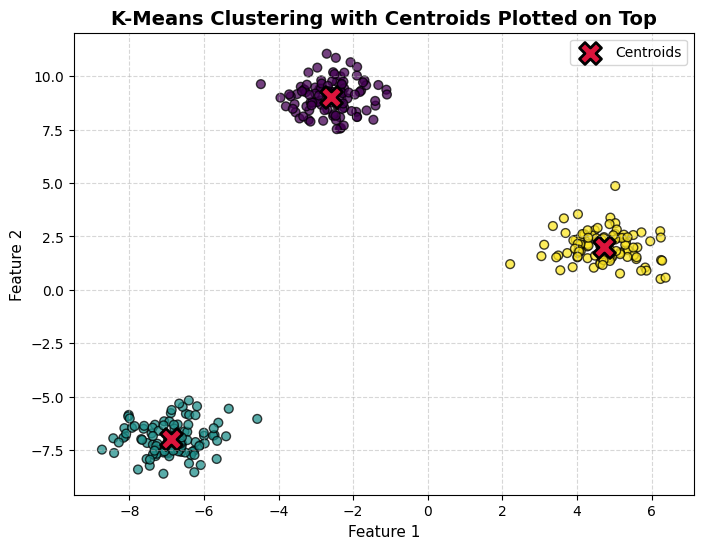

In [17]:
#Q37. Generate synthetic data with make_blobs and apply KMeans. Then plot the cluster centers on top of the
#data points
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 1. Generate synthetic data with 3 natural centers
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.75, random_state=42)

# 2. Instantiate and fit the K-Means algorithm
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init='auto')
y_kmeans = kmeans.fit_predict(X)

# 3. Extract the final calculated cluster centers (centroids)
centroids = kmeans.cluster_centers_

# 4. Generate the visualization plot
plt.figure(figsize=(8, 6))

# Plot the data points color-coded by their K-Means cluster assignments
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', s=40, edgecolors='k', alpha=0.75)

# Overlay the cluster centroids as prominent red 'X' markers on top of the data points
plt.scatter(centroids[:, 0], centroids[:, 1], c='crimson', marker='X',
            s=250, linewidths=2, edgecolors='black', label='Centroids')

plt.title('K-Means Clustering with Centroids Plotted on Top', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1', fontsize=11)
plt.ylabel('Feature 2', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.show()


In [18]:
#Q38. Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data

# 2. Instantiate and fit DBSCAN with default parameters (eps=0.5, min_samples=5)
dbscan = DBSCAN()
labels = dbscan.fit_predict(X)

# 3. Count how many samples were labeled as noise (-1)
# DBSCAN inherently assigns a label of -1 to any point that is not a core or border point
noise_count = list(labels).count(-1)
total_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print(f"Number of clusters found: {total_clusters}")
print(f"Number of noise samples identified: {noise_count}")

Number of clusters found: 2
Number of noise samples identified: 17


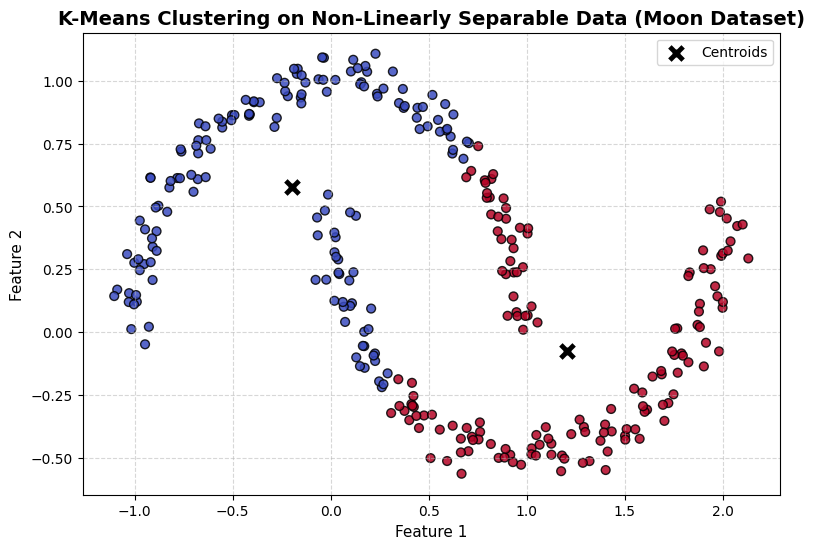

In [19]:
#Q39. Generate synthetic non-linearly separable data using make_moons, apply K-Means, and visualize the
#clustering result
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

# 1. Generate synthetic non-linearly separable moon data
# noise=0.05 keeps the shapes clean and distinct
X, y_true = make_moons(n_samples=300, noise=0.05, random_state=42)

# 2. Apply K-Means clustering (using 2 clusters)
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
y_kmeans = kmeans.fit_predict(X)

# 3. Extract the final calculated centroids
centroids = kmeans.cluster_centers_

# 4. Generate the visualization plot
plt.figure(figsize=(9, 6))

# Scatter plot of the data points color-coded by K-Means predictions
scatter = plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='coolwarm', s=40, edgecolors='k', alpha=0.85)

# Overlay the cluster centroids as large prominent black markers
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X',
            s=200, edgecolors='white', linewidths=1.5, label='Centroids')

plt.title('K-Means Clustering on Non-Linearly Separable Data (Moon Dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1', fontsize=11)
plt.ylabel('Feature 2', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.show()


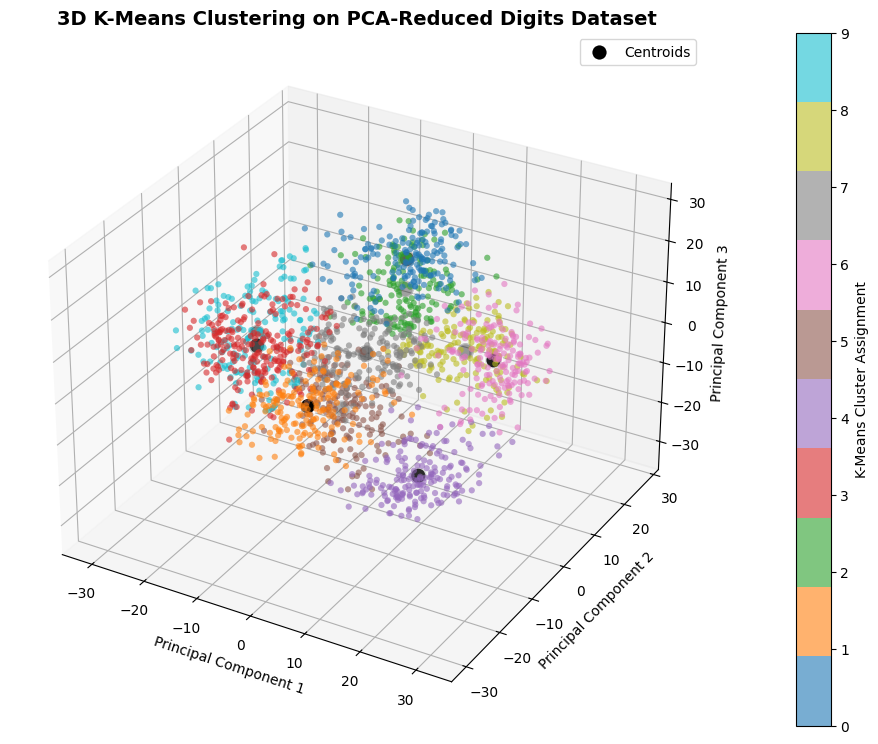

In [20]:
#Q40. Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D
#scatter plot.
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Enables 3D plotting projections
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Load the Digits dataset (8x8 pixel images unrolled into 64 features)
digits = load_digits()
X = digits.data

# 2. Reduce the 64-dimensional pixel array down to 3D using PCA
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X)

# 3. Apply K-Means clustering (using 10 clusters to mirror digits 0-9)
kmeans = KMeans(n_clusters=10, random_state=42, n_init='auto')
y_kmeans = kmeans.fit_predict(X_pca)
centroids = kmeans.cluster_centers_

# 4. Generate the 3D scatter plot visualization
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the 3D projected data points color-coded by K-Means assignments
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                     c=y_kmeans, cmap='tab10', s=20, alpha=0.6, edgecolors='none')

# Overlay the 3D calculated cluster centroids prominently as large black circles
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
           c='black', marker='o', s=150, linewidths=2, edgecolors='white', label='Centroids')

# Set titles and structural labels for the three dimensions
ax.set_title('3D K-Means Clustering on PCA-Reduced Digits Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Principal Component 1', fontsize=10)
ax.set_ylabel('Principal Component 2', fontsize=10)
ax.set_zlabel('Principal Component 3', fontsize=10)
ax.legend(loc='upper right')

# Add a color bar mapping to the 10 distinct cluster IDs
colorbar = fig.colorbar(scatter, ax=ax, pad=0.1)
colorbar.set_label('K-Means Cluster Assignment')

plt.show()

In [21]:
#Q41. Generate synthetic blobs with 5 centers and apply KMeans. Then use silhouette_score to evaluate the
#clustering
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Generate synthetic data with 5 natural centers
X, y_true = make_blobs(n_samples=500, centers=5, cluster_std=0.60, random_state=42)

# 2. Instantiate and fit K-Means with 5 clusters
# Using 'k-means++' initialization ensures fast and optimized convergence
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init='auto')
y_kmeans = kmeans.fit_predict(X)

# 3. Evaluate the model using the Silhouette Score
# This measures how close each point is to its own cluster vs. neighboring clusters
average_silhouette = silhouette_score(X, y_kmeans)

print(f"Number of True Centers: 5")
print(f"Number of K-Means Clusters: 5")
print(f"Average Silhouette Score: {average_silhouette:.4f}")


Number of True Centers: 5
Number of K-Means Clusters: 5
Average Silhouette Score: 0.7993


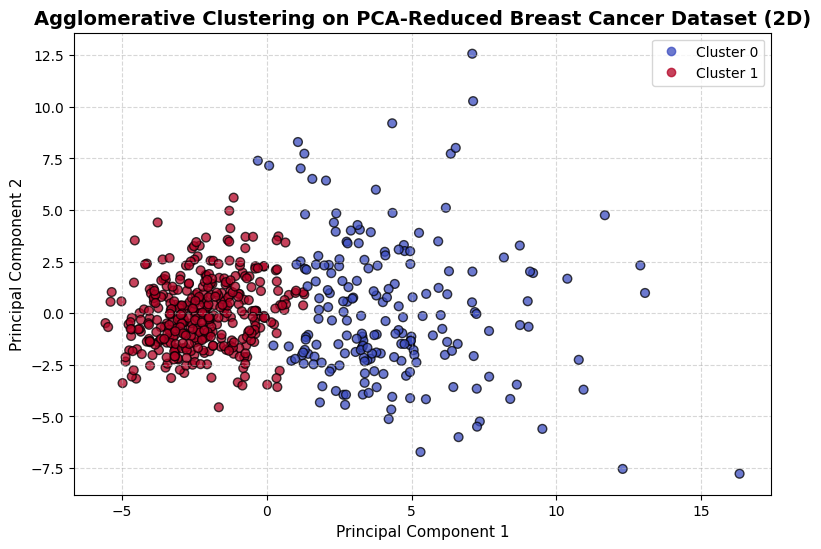

In [22]:
#Q42. Load the Breast Cancer dataset, reduce dimensionality using PCA, and apply Agglomerative Clustering.
#Visualize in 2D
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# 1. Load the Breast Cancer dataset (30 dimensions)
cancer = load_breast_cancer()
X = cancer.data

# 2. Standardize features (essential before executing PCA)
X_scaled = StandardScaler().fit_transform(X)

# 3. Compress the 30 dimensions down to 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 4. Apply Agglomerative Clustering (2 clusters to check for malignant vs benign patterns)
# Using 'ward' linkage minimizes variance during the bottom-up merges
agg_model = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = agg_model.fit_predict(X_pca)

# 5. Generate the 2D visualization plot
plt.figure(figsize=(9, 6))

# Scatter plot of the 2D projected coordinates color-coded by agglomerative labels
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='coolwarm', s=40, edgecolors='k', alpha=0.75)

plt.title('Agglomerative Clustering on PCA-Reduced Breast Cancer Dataset (2D)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=11)
plt.ylabel('Principal Component 2', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Add a legend mapping the discovered cluster tags
handles, _ = scatter.legend_elements()
plt.legend(handles, ['Cluster 0', 'Cluster 1'], loc='upper right')

plt.show()


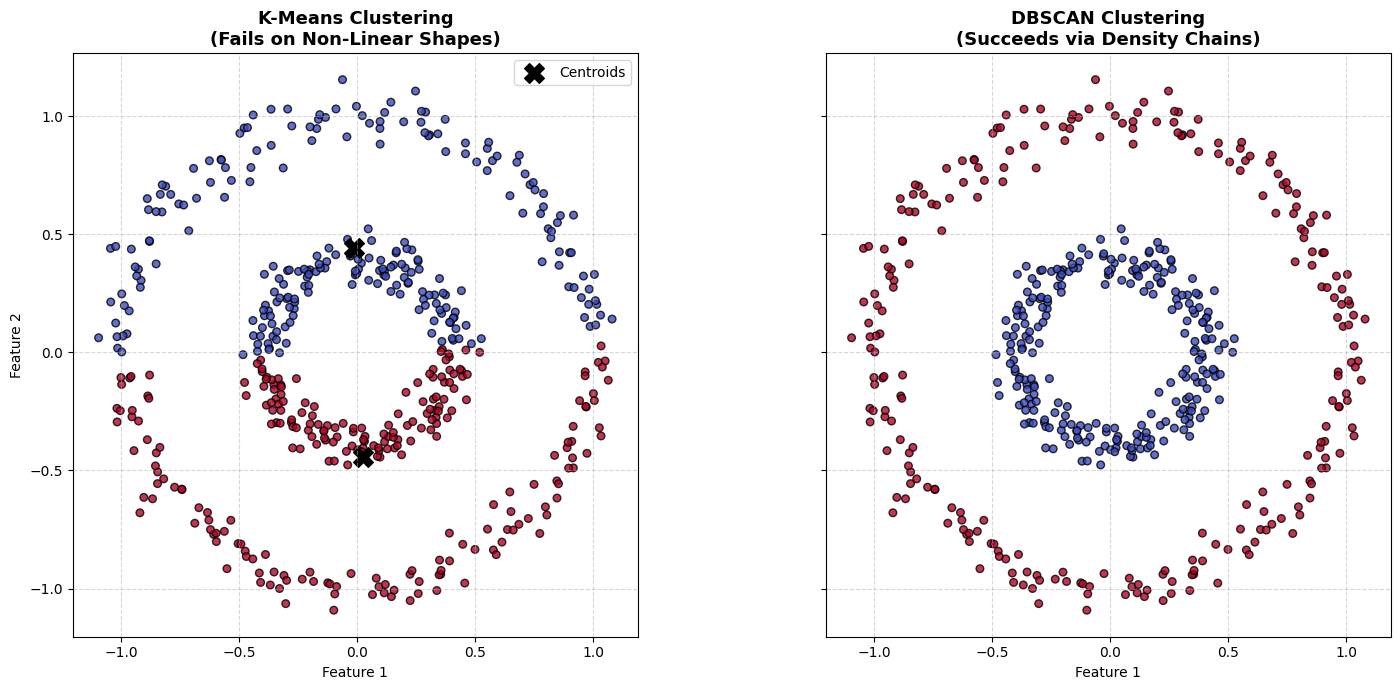

In [23]:
#Q43.  Generate noisy circular data using make_circles and visualize clustering results from KMeans and DBSCAN
#side-by-side
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN

# 1. Generate noisy concentric circles dataset
# factor=0.4 sets a wide gap between rings, noise=0.05 adds spatial variance
X, y_true = make_circles(n_samples=500, factor=0.4, noise=0.05, random_state=42)

# 2. Run K-Means Clustering (Forcing 2 clusters)
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
y_kmeans = kmeans.fit_predict(X)

# 3. Run DBSCAN Clustering (Tuned parameters for density paths)
dbscan = DBSCAN(eps=0.15, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

# 4. Generate side-by-side visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# --- Left Plot: K-Means Failure ---
scatter1 = ax1.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='coolwarm', s=30, edgecolors='k', alpha=0.8)
centroids = kmeans.cluster_centers_
ax1.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, label='Centroids')
ax1.set_title('K-Means Clustering\n(Fails on Non-Linear Shapes)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')
ax1.set_aspect('equal')

# --- Right Plot: DBSCAN Success ---
scatter2 = ax2.scatter(X[:, 0], X[:, 1], c=y_dbscan, cmap='coolwarm', s=30, edgecolors='k', alpha=0.8)
ax2.set_title('DBSCAN Clustering\n(Succeeds via Density Chains)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Feature 1')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_aspect('equal')

# Adjust layout and display
plt.tight_layout()
plt.show()

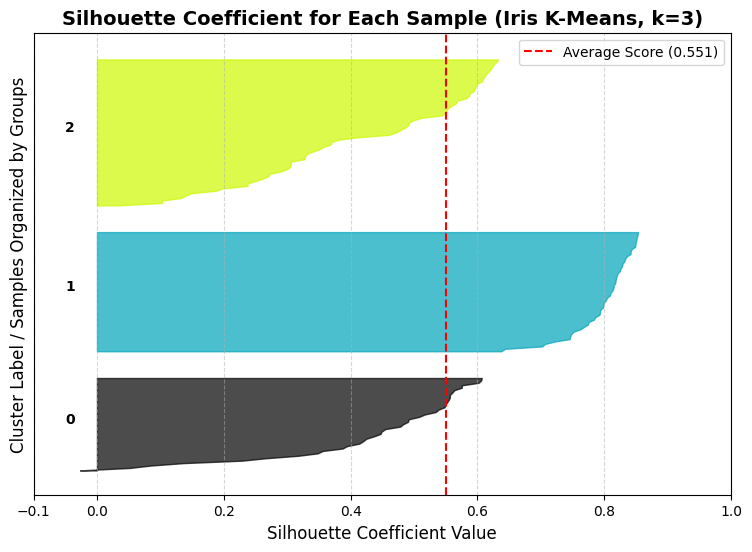

In [24]:
#Q44. Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data

# 2. Fit K-Means clustering with 3 clusters
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X)

# 3. Calculate the overall average score and the individual sample coefficients
average_score = silhouette_score(X, cluster_labels)
sample_silhouette_values = silhouette_samples(X, cluster_labels)

# 4. Generate the Silhouette Plot
fig, ax1 = plt.subplots(1, 1, figsize=(9, 6))

# The silhouette coefficient ranges from -1 to 1, but we focus on the active domain
ax1.set_xlim([-0.1, 1.0])
# The (n_clusters+1)*10 addition provides whitespace between individual cluster plots
ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

y_lower = 10
for i in range(n_clusters):
    # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    # Color each cluster distinctively
    color = cm.nipy_spectral(float(i) / n_clusters)
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontweight='bold')

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 samples space between clusters

plt.title("Silhouette Coefficient for Each Sample (Iris K-Means, k=3)", fontsize=14, fontweight='bold')
plt.xlabel("Silhouette Coefficient Value", fontsize=12)
plt.ylabel("Cluster Label / Samples Organized by Groups", fontsize=12)

# Draw a vertical dashed line representing the global average silhouette score
ax1.axvline(x=average_score, color="red", linestyle="--", linewidth=1.5,
            label=f"Average Score ({average_score:.3f})")

ax1.set_yticks([])  # Clear the literal sample count tick marks on the Y-axis
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax1.grid(axis='x', linestyle='--', alpha=0.5)
ax1.legend(loc="upper right")

plt.show()

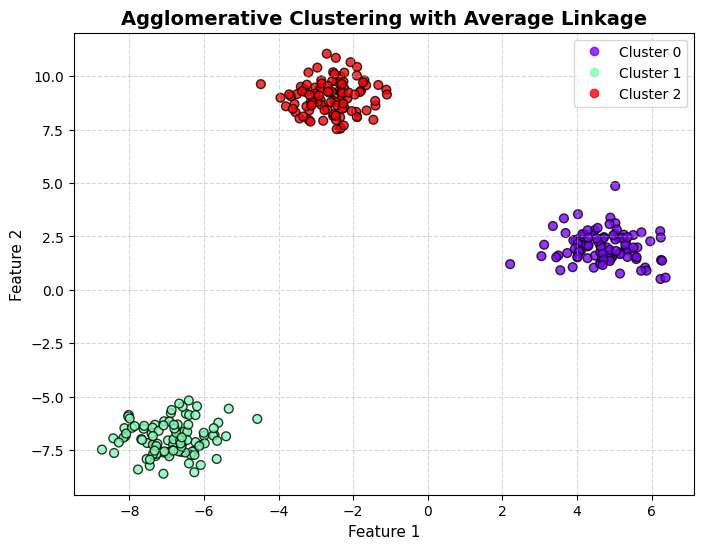

In [25]:
#Q45.  Generate synthetic data using make_blobs and apply Agglomerative Clustering with 'average' linkage.
#Visualize clusters
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

# 1. Generate synthetic data with 3 natural centers
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.75, random_state=42)

# 2. Apply Agglomerative Clustering using average linkage
# Average linkage defines cluster distance by the average of all pairs between them
agg_model = AgglomerativeClustering(n_clusters=3, linkage='average')
y_predicted = agg_model.fit_predict(X)

# 3. Create the scatter plot visualization
plt.figure(figsize=(8, 6))

# Plot the data points color-coded by their agglomerative cluster labels
scatter = plt.scatter(X[:, 0], X[:, 1], c=y_predicted, cmap='rainbow', s=40, edgecolors='k', alpha=0.8)

plt.title('Agglomerative Clustering with Average Linkage', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1', fontsize=11)
plt.ylabel('Feature 2', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Add a clear legend representing the unique discovered clusters
handles, _ = scatter.legend_elements()
plt.legend(handles, ['Cluster 0', 'Cluster 1', 'Cluster 2'], loc='upper right')

plt.show()

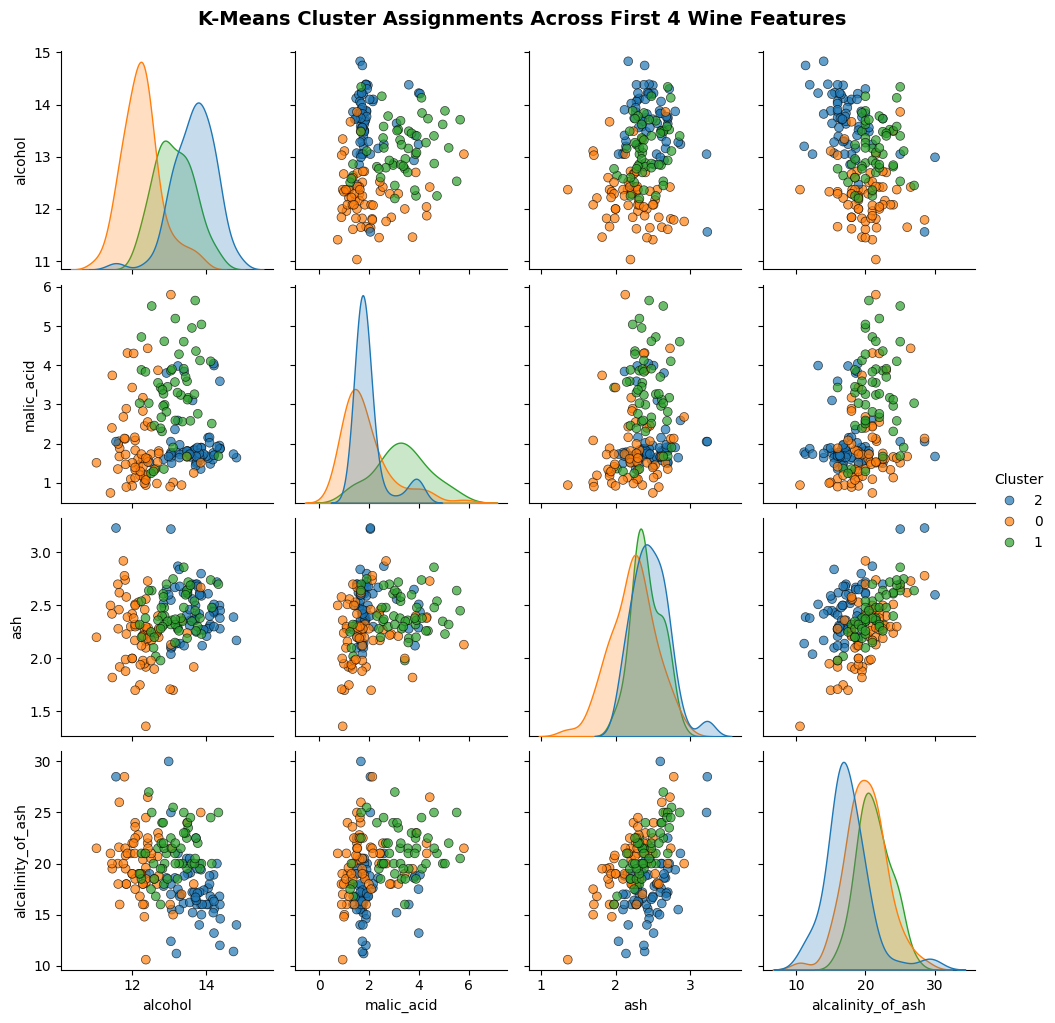

In [26]:
#Q46.  Load the Wine dataset, apply KMeans, and visualize the cluster assignments in a seaborn pairplot (first 4
#features)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load the Wine recognition dataset
wine = load_wine()
X = wine.data

# 2. Standardize features
# Essential because K-Means relies on spatial distance metrics
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fit K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_scaled)

# 4. Construct a pandas DataFrame using the first 4 features
# Features: alcohol, malic_acid, ash, alcalinity_of_ash
feature_names = wine.feature_names[:4]
df = pd.DataFrame(X[:, :4], columns=feature_names)

# Append the K-Means cluster predictions to the DataFrame for color-coding
# Converting to a string category ensures a high-contrast discrete color palette
df['Cluster'] = cluster_labels.astype(str)

# 5. Generate the Seaborn Pairplot matrix
# 'hue' maps the color to the clusters, 'diag_kind' displays density curves on the diagonal
pair_plot = sns.pairplot(df, hue='Cluster', palette='tab10', diag_kind='kde',
                         plot_kws={'alpha': 0.7, 'edgecolor': 'k', 's': 40})

pair_plot.fig.suptitle('K-Means Cluster Assignments Across First 4 Wine Features',
                        y=1.02, fontsize=14, fontweight='bold')
plt.show()


In [27]:
#Q47. Generate noisy blobs using make_blobs and use DBSCAN to identify both clusters and noise points. Print the
#count
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

# 1. Generate synthetic blobs with a higher standard deviation to introduce noise
# cluster_std=1.6 ensures the blobs are spread out and leak points into background space
X, y_true = make_blobs(n_samples=400, centers=3, cluster_std=1.6, random_state=42)

# 2. Fit the DBSCAN algorithm
# eps=1.0 defines the local radius search window
# min_samples=5 demands at least 5 points to declare a core region
dbscan = DBSCAN(eps=1.0, min_samples=5)
labels = dbscan.fit_predict(X)

# 3. Process and count the structural results
# DBSCAN represents discovered clusters with integers starting at 0, 1, 2...
# Any isolated point failing the density threshold is permanently labeled as -1 (noise)
unique_labels = set(labels)

# Calculate total clusters (subtracting 1 if the noise label '-1' exists in the set)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = list(labels).count(-1)

# 4. Print the final counts
print(f"Total data samples evaluated: {len(X)}")
print(f"Number of discovered dense clusters: {n_clusters}")
print(f"Number of identified noise points (-1): {n_noise}")

Total data samples evaluated: 400
Number of discovered dense clusters: 4
Number of identified noise points (-1): 33


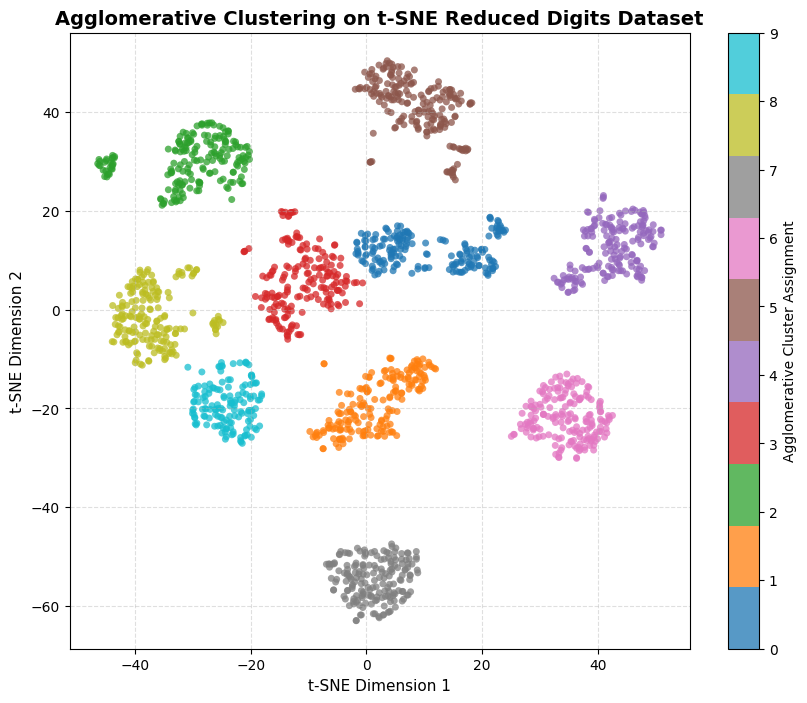

In [28]:
#Q48. Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative Clustering and plot the
#clusters.
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering

# 1. Load the Digits dataset (1797 images, each with 64 pixel features)
digits = load_digits()
X = digits.data

# 2. Reduce dimensions using t-SNE
# t-SNE preserves local configurations, pushing similar digits into dense islands
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X)

# 3. Apply Agglomerative Clustering on the 2D t-SNE projection
# Using 10 clusters to mirror digits 0-9. 'ward' linkage minimizes within-cluster variance.
agg_model = AgglomerativeClustering(n_clusters=10, linkage='ward')
y_agg = agg_model.fit_predict(X_tsne)

# 4. Generate the visualization plot
plt.figure(figsize=(10, 8))

# Scatter plot of the 2D projected data points color-coded by Agglomerative labels
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_agg, cmap='tab10',
            s=25, alpha=0.75, edgecolors='none')

plt.title('Agglomerative Clustering on t-SNE Reduced Digits Dataset', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Dimension 1', fontsize=11)
plt.ylabel('t-SNE Dimension 2', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)

# Add a color bar mapping to the 10 distinct cluster IDs
colorbar = plt.colorbar(scatter)
colorbar.set_label('Agglomerative Cluster Assignment')

plt.show()
